In [76]:
# Understanding the Finding of both m and b at a time using Gradient Descent with Visuals 

%matplotlib inline 

from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from IPython.display import HTML

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [67]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

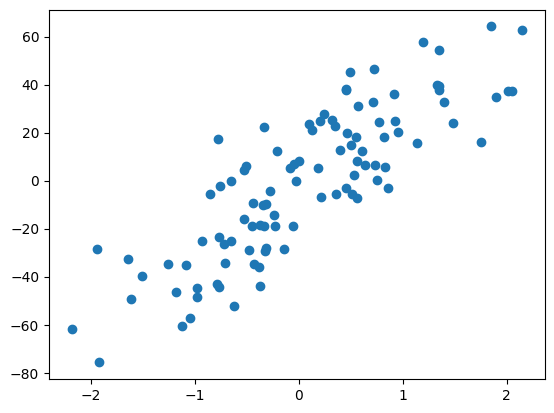

In [68]:
plt.scatter(X,y)

In [69]:
b = 0
m = 0
lr = 0.001
all_b = []
all_m = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope_b = 0
    slope_m = 0
    cost = 0
    for j in range(X.shape[0]):
        slope_b = slope_b - 2*(y[j] - (m * X[j]) -  b)
        slope_m = slope_m - 2*(y[j] - (m * X[j]) -  b)*X[j]
        cost = cost + (y[j] - m * X[j] -b) ** 2

    b = b - (lr * slope_b)
    m = m - (lr * slope_m)
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

In [70]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.linspace(X.min(), X.max(), 100)
ax.scatter(X, y)
line, = ax.plot(x_i, x_i*all_m[0] + all_b[0], 'r--', linewidth=2)

# Add these lines to set proper axis limits
ax.set_xlim(X.min() - 0.5, X.max() + 0.5)  # Set x-axis limits based on data
ax.set_ylim(y.min() - 20, y.max() + 20)    # Set y-axis limits based on data

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*all_m[i] + all_b[i])
    ax.set_xlabel(label)
    return line,

anim = FuncAnimation(fig, update, repeat=True, frames=epochs, interval=500)

plt.close()
HTML(anim.to_jshtml())

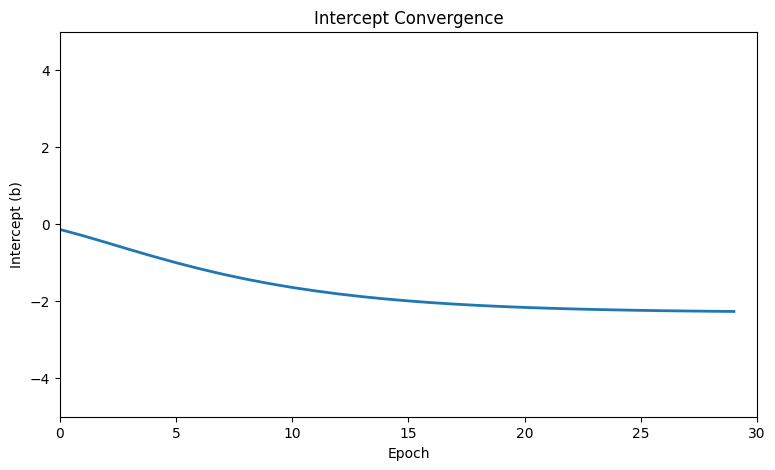

In [71]:
# Intercept (b) convergence - Static graph
plt.figure(figsize=(9,5))
plt.plot(range(len(all_b)), all_b, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Intercept (b)')
plt.title('Intercept Convergence')
plt.xlim(0, 30)
plt.ylim(-5, 5)
plt.show()

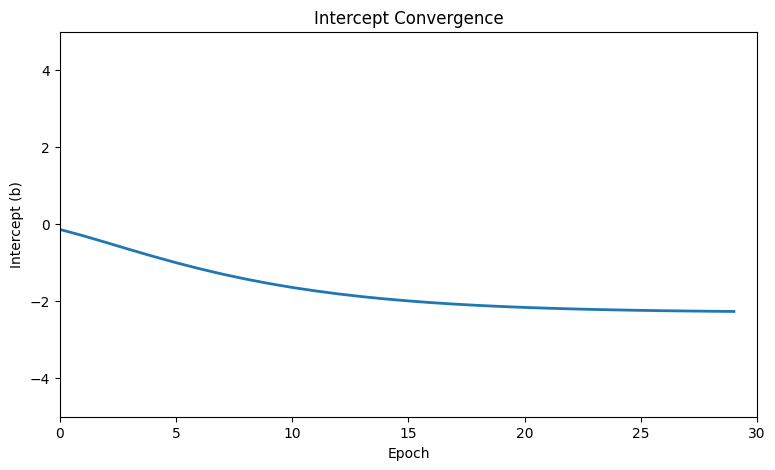

In [75]:
plt.figure(figsize=(9,5))
plt.plot(range(len(all_b)), all_b, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Intercept (b)')
plt.title('Intercept Convergence')
plt.xlim(0, 30)
plt.ylim(-5, 5)  # Changed limits since b goes from 0 to -2
plt.show()

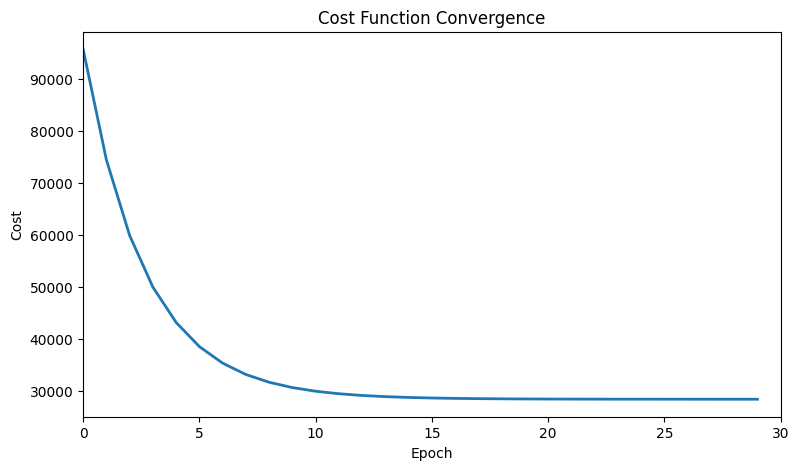

In [73]:
# Cost function - Static graph
plt.figure(figsize=(9,5))
plt.plot(range(len(all_cost)), all_cost, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Cost Function Convergence')
plt.xlim(0, 30)
plt.show()

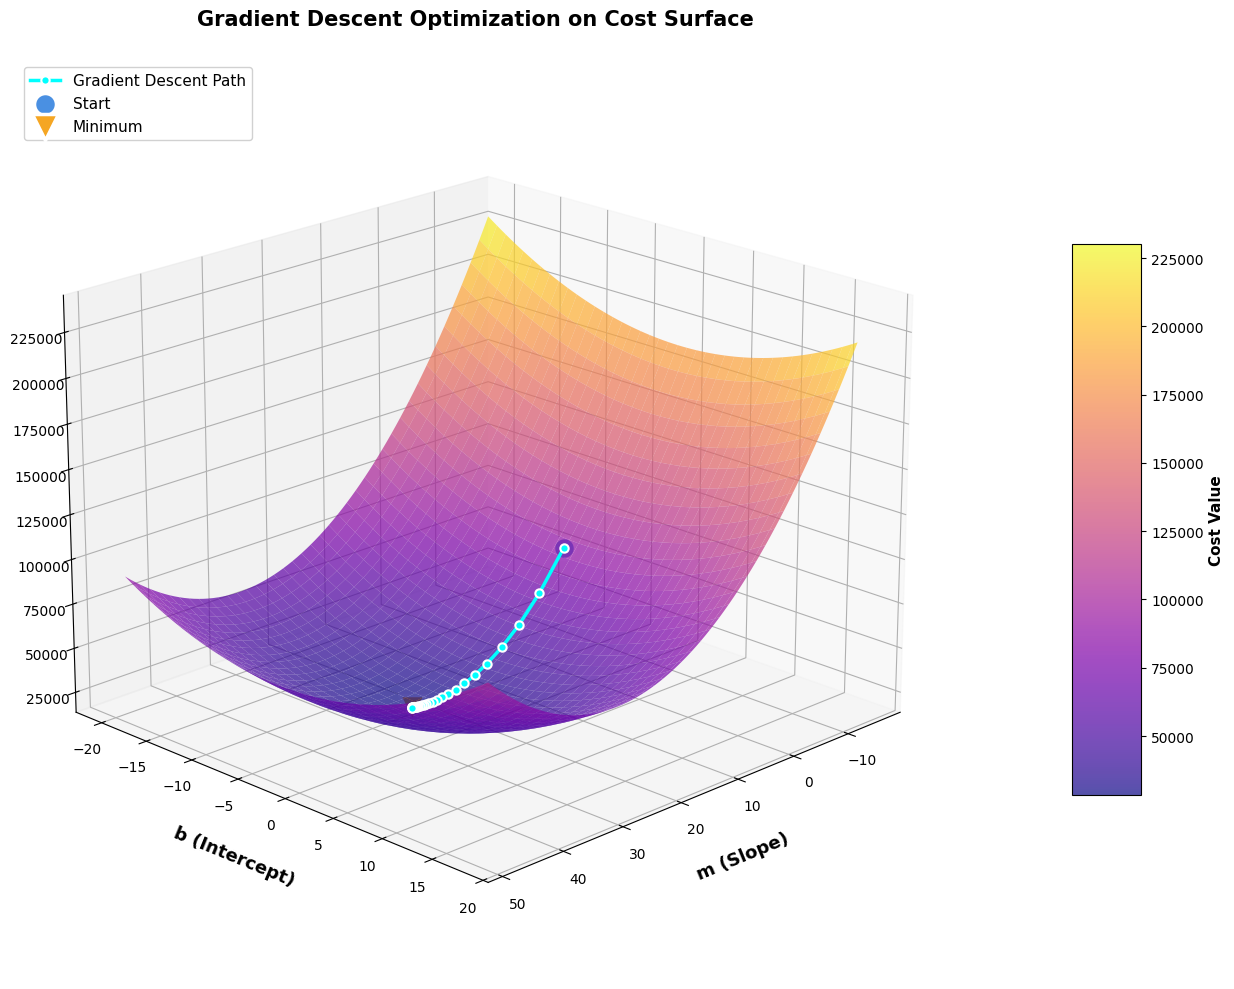

In [78]:
# Create mesh grid (smaller range for better visualization)
m_range = np.linspace(all_m[0] - 20, all_m[-1] + 20, 80)
b_range = np.linspace(all_b[0] - 20, all_b[-1] + 20, 80)
M, B = np.meshgrid(m_range, b_range)

# Calculate cost surface
def calc_cost(m, b):
    predictions = m * X + b
    return np.sum((y - predictions.ravel()) ** 2)

Z = np.zeros_like(M)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        Z[i, j] = calc_cost(M[i, j], B[i, j])

# Create figure
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with nice gradient
surf = ax.plot_surface(M, B, Z, cmap='plasma', alpha=0.7, 
                       edgecolor='none', antialiased=True, vmin=Z.min(), vmax=Z.max())

# Plot gradient descent path
path = ax.plot(all_m, all_b, all_cost, 
              'o-', color='cyan', markersize=6, linewidth=2.5, 
              markeredgecolor='white', markeredgewidth=1.5, 
              label='Gradient Descent Path', zorder=10)

# Starting point
ax.scatter([all_m[0]], [all_b[0]], [all_cost[0]], 
          color='#4A90E2', s=250, marker='o', 
          edgecolors='white', linewidths=2.5, 
          label='Start', zorder=11)

# Ending point (minimum)
ax.scatter([all_m[-1]], [all_b[-1]], [all_cost[-1]], 
          color='#F5A623', s=350, marker='v', 
          edgecolors='white', linewidths=2.5, 
          label='Minimum', zorder=11)

# Styling
ax.set_xlabel('\n\nm (Slope)', fontsize=13, fontweight='bold')
ax.set_ylabel('\n\nb (Intercept)', fontsize=13, fontweight='bold')
ax.set_zlabel('\n\nCost', fontsize=13, fontweight='bold')
ax.set_title('Gradient Descent Optimization on Cost Surface', 
            fontsize=15, fontweight='bold', pad=25)

# Adjust viewing angle
ax.view_init(elev=20, azim=45)

# Legend
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

# Colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=8, pad=0.1)
cbar.set_label('Cost Value', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
